## Import Libraries

In [24]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [25]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [26]:
# Transform to turn into tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081,)), # mean y std
    transforms.Lambda( lambda x: (x > 0.5).float() )
])

In [27]:
# Load the dataset and normalize it
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

## Prepare test dataset

In [28]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda( lambda x: (x > 0.5).float() )
])

In [29]:
# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Examples

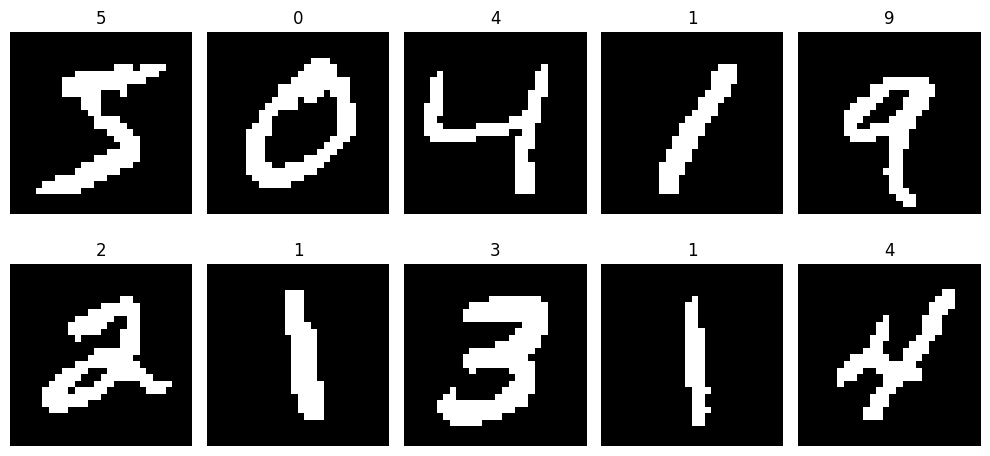

In [30]:
fig, axes = plt.subplots(2,5,figsize=(10,5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    image_np = image.squeeze().numpy()

    ax.imshow(image_np, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Data Loaders

In [31]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1028,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

## Feed Forward Network 

In [32]:
# All variables
%whos

Variable                 Type          Data/Info
------------------------------------------------
DataLoader               type          <class 'torch.utils.data.dataloader.DataLoader'>
F                        module        <module 'torch.nn.functio<...>/torch/nn/functional.py'>
X                        Tensor        tensor([[[[0., 0., 0.,  .<...>0.,  ..., 0., 0., 0.]]]])
ax                       Axes          Axes(0.803,0.0842011;0.182x0.364)
axes                     ndarray       2x5: 10 elems, type `object`, 80 bytes
cols                     int           5
createTheMNISTNet        function      <function createTheMNISTNet at 0x7f6259141580>
datasets                 module        <module 'torchvision.data<...>on/datasets/__init__.py'>
device                   device        cuda
error_idx                Tensor        tensor(57)
errors                   Tensor        tensor([   0,    2,    4,<...>  ..., 2048, 2049, 2050])
fig                      Figure        Figure(1000x500)
functi

In [33]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: AMD Radeon RX 6600


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [41]:
def createTheMNISTNet():

    class mnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(784,64) # 784 pixels

            # hidden layer
            self.fc1 = nn.Linear(64,32)
            self.fc2 = nn.Linear(32,32)

            # output layer
            self.output = nn.Linear(32,10)

        def forward(self,x):
            x = x.view(x.shape[0], -1)
            
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )
            return torch.log_softmax( self.output(x), dim=1 )

    net = mnistNet()

    lossfun = nn.NLLLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=0.1) # try with Adam later

    return net, lossfun, optimizer

In [42]:
net, lossfun, optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

print(yHat)

loss = lossfun(yHat, y)
print(' ')
print('Loss:')
print(loss)

tensor([[-2.4488, -2.4916, -2.3766,  ..., -2.2542, -2.1437, -2.2792],
        [-2.4481, -2.4929, -2.3767,  ..., -2.2466, -2.1459, -2.2798],
        [-2.4545, -2.4995, -2.3835,  ..., -2.2339, -2.1791, -2.2842],
        ...,
        [-2.4559, -2.4956, -2.3603,  ..., -2.2469, -2.1576, -2.2772],
        [-2.4644, -2.5060, -2.3683,  ..., -2.2490, -2.1428, -2.2744],
        [-2.4694, -2.5064, -2.3810,  ..., -2.2360, -2.1683, -2.2742]],
       grad_fn=<LogSoftmaxBackward0>)
 
Loss:
tensor(2.3104, grad_fn=<NllLossBackward0>)


## Training

In [43]:
def function2trainTheModel():

    numepochs = 60

    net, lossfun, optimizer = createTheMNISTNet()
    net.to(device)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            X, y = X.to(device), y.to(device)
            
            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # back
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # loss
            batchLoss.append( loss.item() )

            # accuracy
            matches = torch.argmax(yHat, axis=1) == y # predictions
            matchesNumeric = matches.float() # to numeric
            accuracyPct = 100*torch.mean(matchesNumeric) # pct of mean
            batchAcc.append( accuracyPct.item() ) # add

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        # ===== Test =====
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)
        yHat = net(X)

        acc = 100*torch.mean( (torch.argmax(yHat, axis=1)==y).float() )
        testAcc.append( acc.item() )
        
        print(f'Epoch: {epochi} \f trainAcc: {trainAcc[epochi]} \f testAcc: {testAcc[epochi]}')

    return trainAcc, testAcc, losses, net

In [44]:
trainAcc, testAcc, losses, net = function2trainTheModel()

Epoch: 0  trainAcc: 27.116720085470085  testAcc: 58.94941711425781
Epoch: 1  trainAcc: 73.8681891025641  testAcc: 85.60311126708984
Epoch: 2  trainAcc: 86.50841346153847  testAcc: 87.64591217041016
Epoch: 3  trainAcc: 89.00073450854701  testAcc: 90.75875091552734
Epoch: 4  trainAcc: 90.77690972222223  testAcc: 90.36964416503906
Epoch: 5  trainAcc: 91.89703525641026  testAcc: 92.70427703857422
Epoch: 6  trainAcc: 92.85690438034187  testAcc: 93.9688720703125
Epoch: 7  trainAcc: 93.60810630341881  testAcc: 92.31517028808594
Epoch: 8  trainAcc: 94.3843482905983  testAcc: 94.6498031616211
Epoch: 9  trainAcc: 94.86845619658119  testAcc: 95.23346710205078
Epoch: 10  trainAcc: 95.26575854700855  testAcc: 95.03890991210938
Epoch: 11  trainAcc: 95.59294871794872  testAcc: 94.74708557128906
Epoch: 12  trainAcc: 95.90845352564102  testAcc: 95.71984100341797
Epoch: 13  trainAcc: 96.17053952991454  testAcc: 95.23346710205078
Epoch: 14  trainAcc: 96.3959001068376  testAc

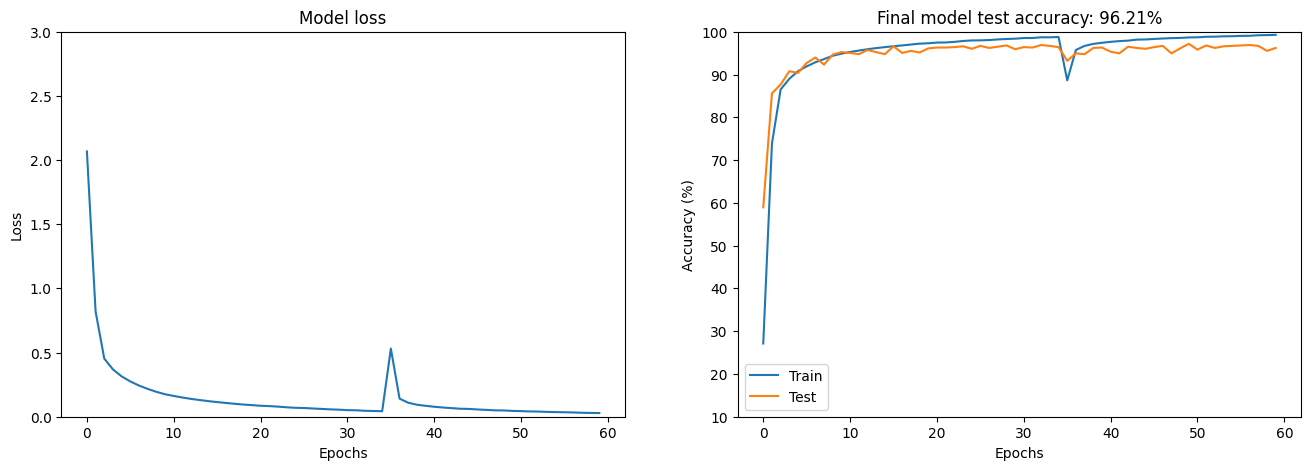

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()


Se encontraron 33 errores en este batch.




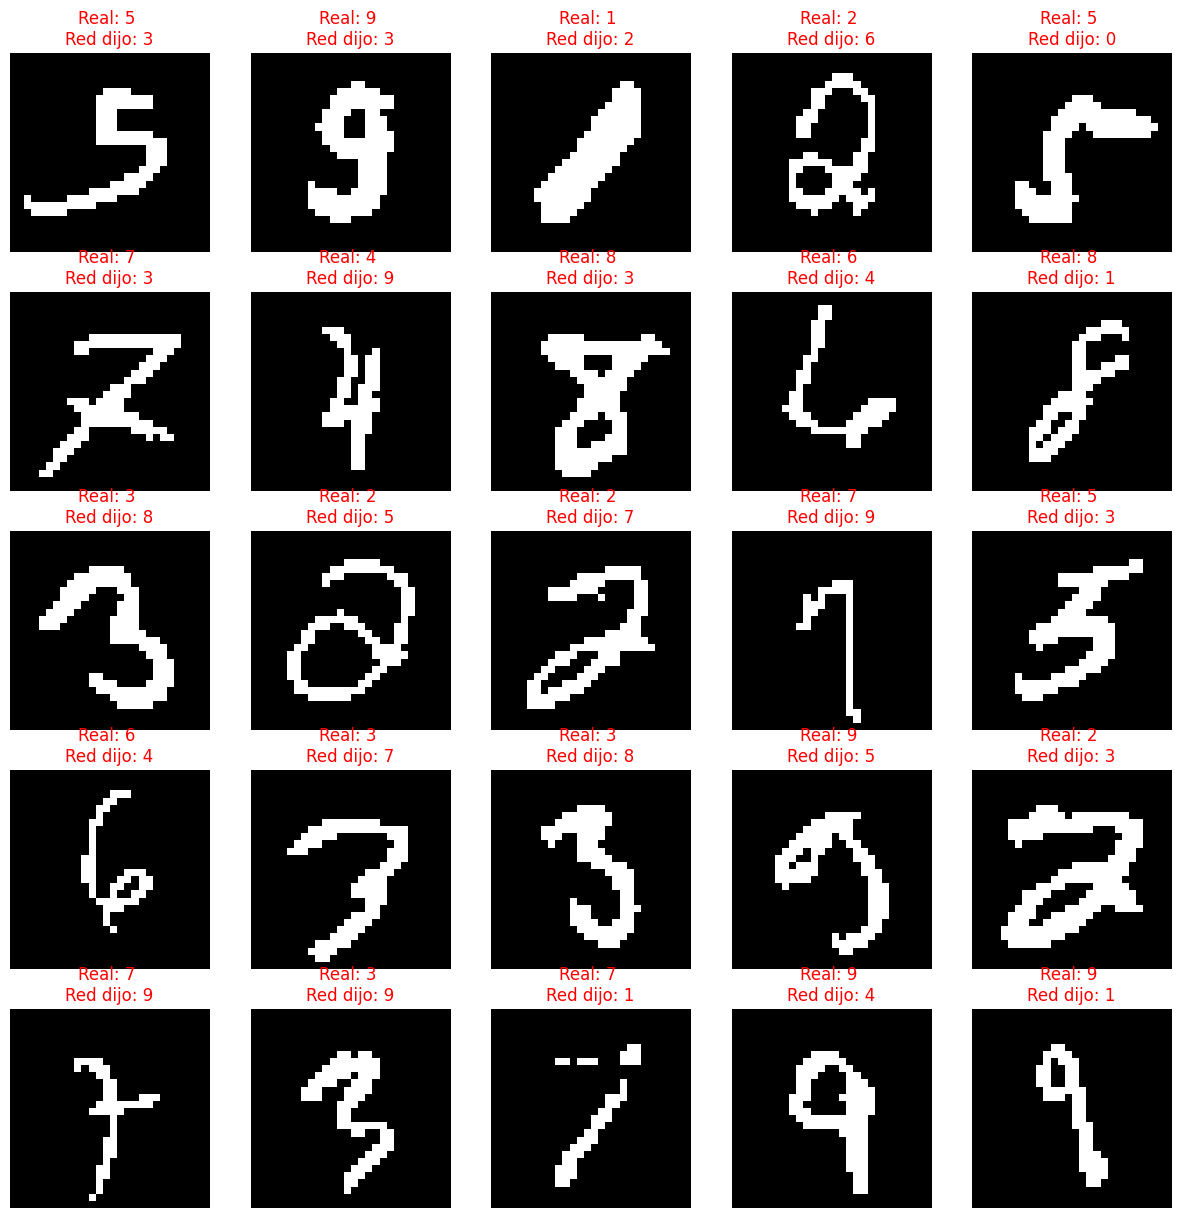

In [46]:
import math
import matplotlib.pyplot as plt
import torch

X, y = next(iter(test_loader))
X, y = X.to(device), y.to(device)

with torch.no_grad():
    predictions = net(X)

predictions = predictions.cpu()
y = y.cpu()
X = X.cpu()

predicted_classes = torch.argmax(predictions, dim=1)
errors = torch.where(predicted_classes != y)[0]

num_errors = len(errors)
print(f'\nSe encontraron {num_errors} errores en este batch.\n\n')

if num_errors > 0:
    max_to_show = min(num_errors, 25) 
    
    cols = 5 
    rows = math.ceil(max_to_show / cols)
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i in range(max_to_show):
        error_idx = errors[i]
        true_val = y[error_idx].item()
        guess_val = predicted_classes[error_idx].item()
        
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_to_show = X[error_idx].view(28, 28)
        ax.imshow(img_to_show, cmap='gray')
        
        ax.set_title(f'Real: {true_val} \nRed dijo: {guess_val}', color='red')
        ax.axis('off') 